In [234]:
import math
import sys
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

In [235]:
import random
from collections import deque

def generate_maze(rows, cols, path_probability=0.3):
    """
    Generates a random maze with the given dimensions.
    - 1 represents open path.
    - 0 represents walls.
    There is always a guaranteed path from (0, 0) to (rows-1, cols-1).

    Parameters:
        rows (int): Number of rows in the maze.
        cols (int): Number of columns in the maze.
        path_probability (float): Probability of a cell being a path (1) outside the guaranteed path.

    Returns:
        list[list[int]]: A 2D maze grid.
    """
    maze = [[0 for _ in range(cols)] for _ in range(rows)]
    x, y = 0, 0
    maze[x][y] = 1
    while (x, y) != (rows - 1, cols - 1):
        if x < rows - 1 and (y == cols - 1 or random.random() > 0.5):
            x += 1  # Move down
        else:
            y += 1  # Move right
        maze[x][y] = 1
    for i in range(rows):
        for j in range(cols):
            if maze[i][j] == 0 and random.random() < path_probability:
                maze[i][j] = 1
    return maze

In [236]:
class Node:
    def __init__(self, state, parent=None, action=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost

    @staticmethod
    def root(state):
        return Node(state)
    @staticmethod
    def child(problem, parent, action):
        next_state = problem.result(parent.state, action)
        return Node(next_state, parent, action, parent.path_cost + 1)

    def path(self):
        node, path_back = self, []
        while node:
            path_back.append(node.state)
            node = node.parent
        return list(reversed(path_back))

    def __lt__(self, other):
        """Used for comparing nodes in a priority queue."""
        return self.path_cost < other.path_cost # Added indentation here

In [237]:
def visualize_maze(maze, path=None):
    """
    Visualizes the maze using matplotlib, and highlights the path.

    Parameters:
        maze (list[list[int]]): A 2D list representing the maze.
        path (list[tuple[int]]): A list of coordinates representing the path.
    """
    rows, cols = len(maze), len(maze[0])
    grid = np.array(maze)

    # Set up the color map
    cmap = colors.ListedColormap(['black', 'white'])
    bounds = [0, 0.5, 1]  # Boundary for the color map
    norm = colors.BoundaryNorm(bounds, cmap.N)

    # Plot the maze
    fig, ax = plt.subplots(figsize=(cols, rows))
    ax.imshow(grid, cmap=cmap, norm=norm)

    # Add grid lines
    ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='minor', size=0)
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    # Highlight the start and goal positions
    ax.text(0, 0, 'S', ha='center', va='center', color='green', fontsize=12, fontweight='bold')
    ax.text(cols - 1, rows - 1, 'G', ha='center', va='center', color='red', fontsize=12, fontweight='bold')

    # Highlight the path
    if path:
        for (x, y) in path:
            ax.plot(y, x, marker='o', color='blue', markersize=5)

    plt.show()



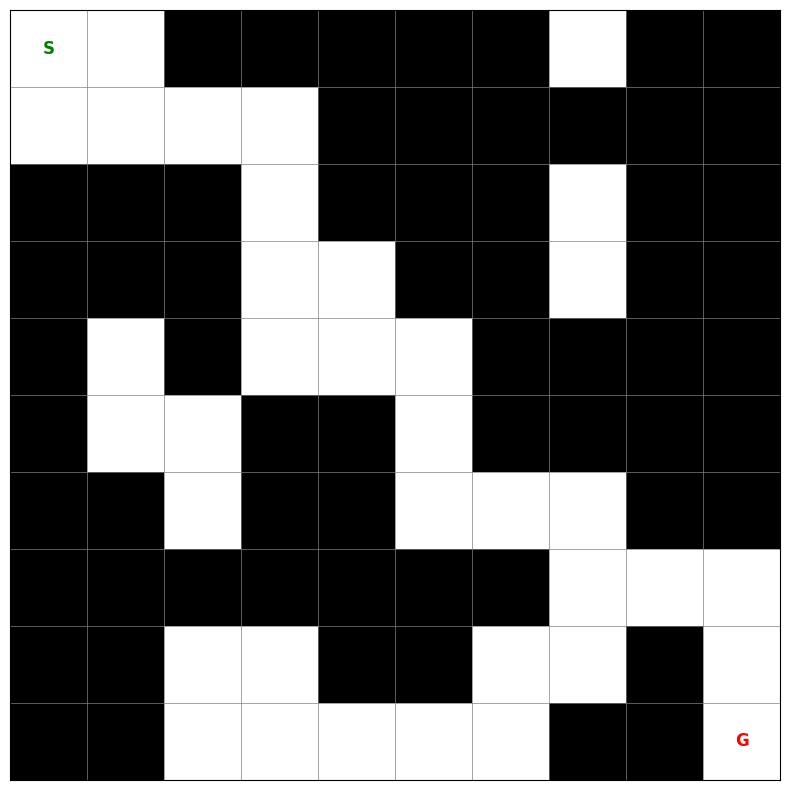

In [238]:
# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = generate_maze(rows, cols, path_probability=0.3)
visualize_maze(maze)


In [239]:
def solution(node):
    return node.path()

In [240]:
class Problem:
    def __init__(self, maze, init_state, goal_state):
        self.maze = maze
        self.init_state = init_state
        self.goal_state = goal_state

    def actions(self, state):
        x, y = state
        actions = []
        if x > 0 and self.maze[x-1][y] == 1:  # Up
            actions.append((x-1, y))
        if x < len(self.maze)-1 and self.maze[x+1][y] == 1:  # Down
            actions.append((x+1, y))
        if y > 0 and self.maze[x][y-1] == 1:  # Left
            actions.append((x, y-1))
        if y < len(self.maze[0])-1 and self.maze[x][y+1] == 1:  # Right
            actions.append((x, y+1))
        return actions

    def result(self, state, action):
        return action

    def goal_test(self, state):
        return state == self.goal_state

    def heuristic(self, state):
        # Define the heuristic function for your problem
        # Example: Manhattan distance for grid-based problems
        return abs(state[0] - self.goal_state[0]) + abs(state[1] - self.goal_state[1])

    def euclidean_heuristic(self, state):
        """Euclidean distance heuristic."""
        return math.sqrt((state[0] - self.goal_state[0]) ** 2 + (state[1] - self.goal_state[1]) ** 2)



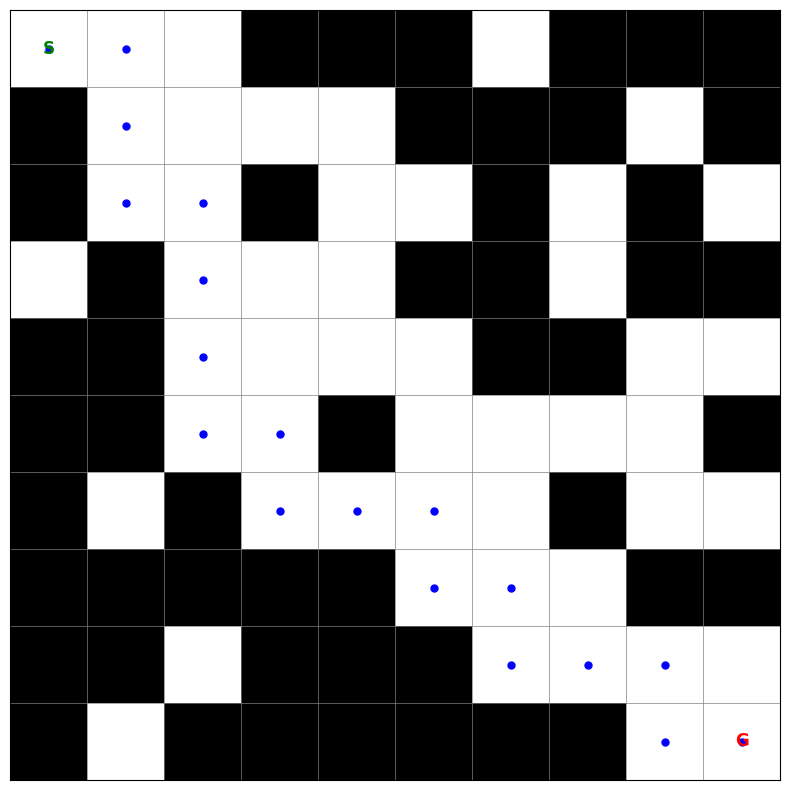

In [241]:
def breadth_first_tree_search(problem):
    frontier = deque([Node.root(problem.init_state)])
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        node = frontier.popleft()
        if problem.goal_test(node.state):
            # Return the path from start to goal
            path = []
            while node:
                path.append(node.state)
                node = node.parent
            return path[::-1], max_frontier_size

        children = [Node.child(problem, node, action) for action in problem.actions(node.state)]
        for child in children:
            if child.state not in visited:
                visited.add(child.state)
                frontier.append(child)

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size


rows, cols = 10, 10  # Maze dimensions
maze = generate_maze(rows, cols, path_probability=0.3)

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform BFS search to find the path
path, _ = breadth_first_tree_search(problem)

# Visualize the maze with the found path
visualize_maze(maze,path)


In [242]:
rows, cols = 2000, 2000
maze = generate_maze(rows, cols)

In [243]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = breadth_first_tree_search(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)


Path to goal: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (6, 4), (6, 5), (7, 5), (7, 6), (7, 7), (7, 8), (8, 8), (8, 9), (9, 9), (10, 9), (10, 10), (10, 11), (11, 11), (11, 12), (12, 12), (13, 12), (13, 13), (13, 14), (13, 15), (13, 16), (14, 16), (14, 17), (14, 18), (15, 18), (15, 19), (15, 20), (16, 20), (16, 21), (16, 22), (16, 23), (17, 23), (17, 24), (18, 24), (18, 25), (18, 26), (19, 26), (20, 26), (21, 26), (22, 26), (23, 26), (24, 26), (24, 27), (24, 28), (24, 29), (24, 30), (24, 31), (24, 32), (24, 33), (25, 33), (26, 33), (26, 34), (27, 34), (28, 34), (29, 34), (29, 35), (30, 35), (30, 36), (30, 37), (31, 37), (31, 38), (31, 39), (32, 39), (33, 39), (33, 40), (33, 41), (34, 41), (34, 42), (34, 43), (34, 44), (34, 45), (34, 46), (34, 47), (34, 48), (34, 49), (34, 50), (35, 50), (36, 50), (36, 51), (37, 51), (38, 51), (38, 52), (38, 53), (39, 53), (39, 54), (39, 55), (39, 56), (39, 57), (40, 57), (41, 57), (42, 57), (42, 58), (42, 59), (43,

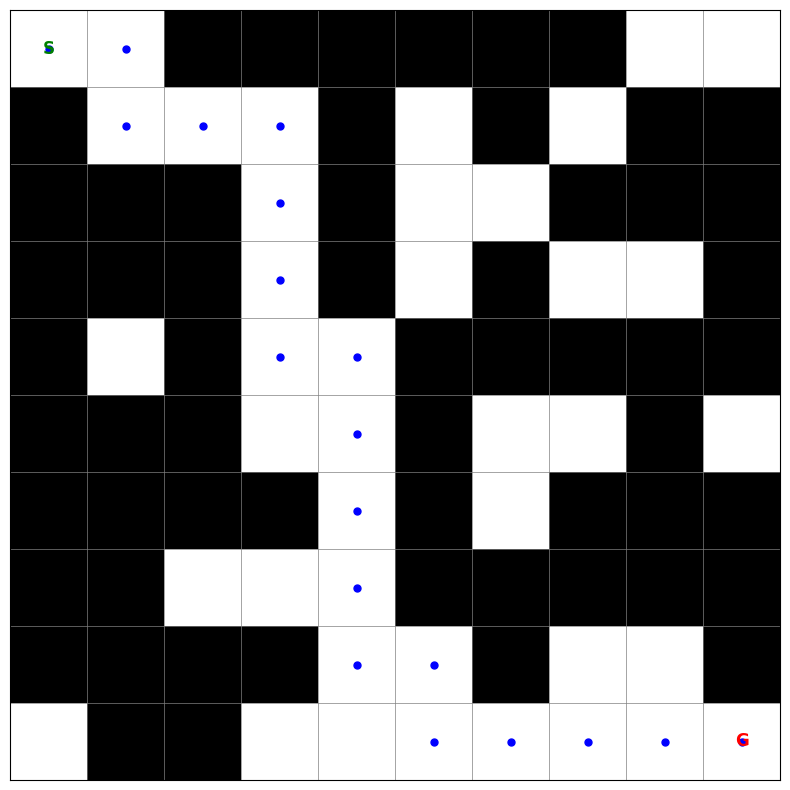

In [244]:
def depth_first_tree_search(problem):
    frontier = [Node.root(problem.init_state)]
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        node = frontier.pop()

        if problem.goal_test(node.state):
            # Return the path from start to goal
            path = []
            while node:
                path.append(node.state)
                node = node.parent
            return path[::-1], max_frontier_size

        children = [Node.child(problem, node, action) for action in problem.actions(node.state)]
        for child in children:
            if child.state not in visited:
                visited.add(child.state)
                frontier.append(child)

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size

# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = generate_maze(rows, cols, path_probability=0.3)

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform DFS search to find the path
path, _ = depth_first_tree_search(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)

In [245]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = depth_first_tree_search(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (4, 4), (5, 4), (6, 4), (7, 4), (8, 4), (8, 5), (9, 5), (9, 6), (9, 7), (9, 8), (9, 9)]
Max frontier size: 5


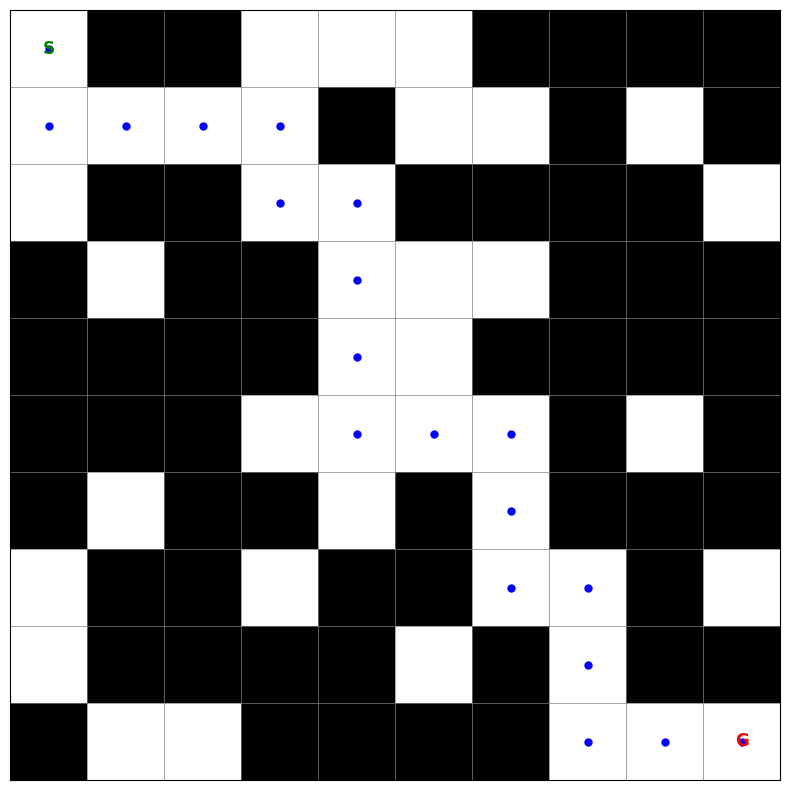

In [246]:
def uniform_cost_search(problem):
    frontier = []
    heapq.heappush(frontier, Node.root(problem.init_state))
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        node = heapq.heappop(frontier)

        if problem.goal_test(node.state):
            # Return the path from start to goal
            path = node.path()
            return path, max_frontier_size

        for action in problem.actions(node.state):
            child = Node.child(problem, node, action)
            if child.state not in visited:
                visited.add(child.state)
                heapq.heappush(frontier, child)

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size

# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = generate_maze(rows, cols, path_probability=0.3)

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform UCS search to find the path
path, _ = uniform_cost_search(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)

In [247]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = uniform_cost_search(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 4), (5, 4), (5, 5), (5, 6), (6, 6), (7, 6), (7, 7), (8, 7), (9, 7), (9, 8), (9, 9)]
Max frontier size: 6


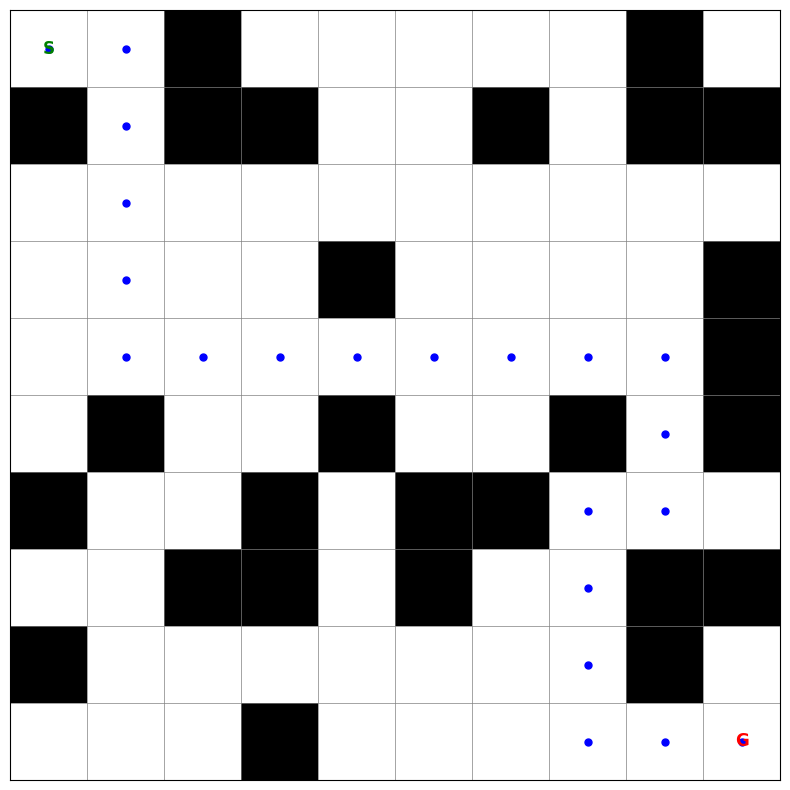

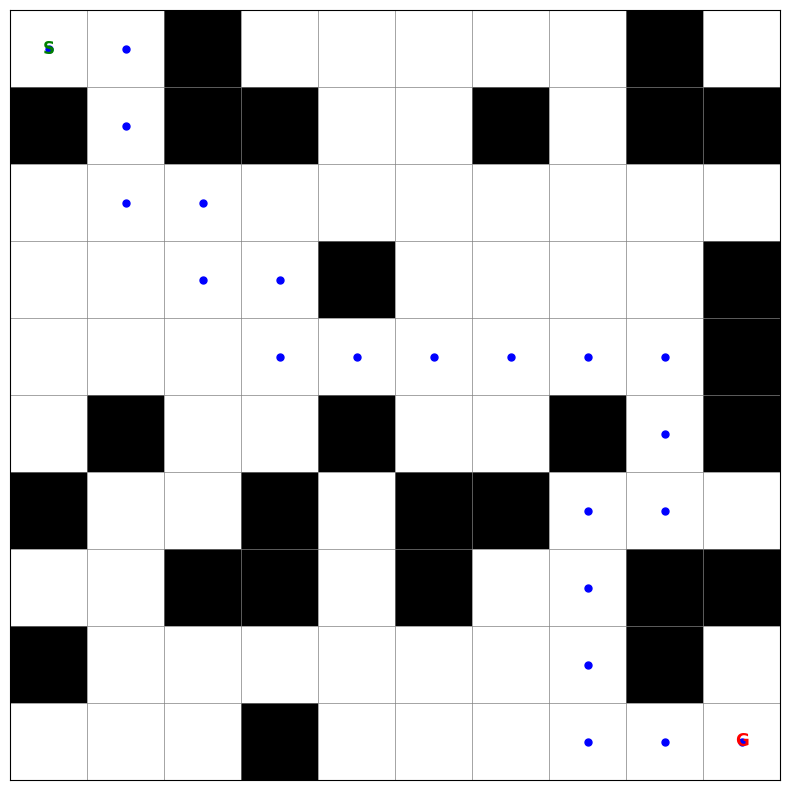

In [277]:
def manhattan_distance(state, goal_state):
    """Calculate Manhattan distance heuristic."""
    return abs(state[0] - goal_state[0]) + abs(state[1] - goal_state[1])

def euclidean_distance(state, goal_state):
    """Calculate Euclidean distance heuristic."""
    return math.sqrt((state[0] - goal_state[0]) ** 2 + (state[1] - goal_state[1]) ** 2)

def A_star_search_With_manhattan_distance(problem):
    frontier = []
    initial_node = Node.root(problem.init_state)
    f_cost = initial_node.path_cost + manhattan_distance(initial_node.state, problem.goal_state)
    heapq.heappush(frontier, (f_cost, initial_node))
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        f_cost, node = heapq.heappop(frontier)

        if problem.goal_test(node.state):
            return node.path(), max_frontier_size

        children = [Node.child(problem, node, action) for action in problem.actions(node.state)]
        for child in children:
            if child.state not in visited:
                visited.add(child.state)
                f_cost = child.path_cost + manhattan_distance(child.state, problem.goal_state)
                heapq.heappush(frontier, (f_cost, child))

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size


def A_star_search_With_euclidean_distance(problem):
    frontier = []
    initial_node = Node.root(problem.init_state)
    f_cost = initial_node.path_cost + euclidean_distance(initial_node.state, problem.goal_state)
    heapq.heappush(frontier, (f_cost, initial_node))
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        f_cost, node = heapq.heappop(frontier)

        if problem.goal_test(node.state):
            return node.path(), max_frontier_size

        children = [Node.child(problem, node, action) for action in problem.actions(node.state)]
        for child in children:
            if child.state not in visited:
                visited.add(child.state)
                f_cost = child.path_cost + euclidean_distance(child.state, problem.goal_state)
                heapq.heappush(frontier, (f_cost, child))

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size
rows, cols = 10, 10  # Maze dimensions
maze = np.random.choice([0, 1], size=(rows, cols), p=[0.3, 0.7])
maze[0][0] = maze[rows-1][cols-1] = 1  # Ensure start and goal are paths

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# A* Search with Manhattan distance
path_manhattan, _ = A_star_search_With_manhattan_distance(problem)

# Visualize the maze with the Manhattan path
visualize_maze(maze, path_manhattan)

# A* Search with Euclidean distance
path_euclidean, _ = A_star_search_With_euclidean_distance(problem)

# Visualize the maze with the Euclidean path
visualize_maze(maze, path_euclidean)


In [250]:
rows, cols = 2000, 2000
maze = generate_maze(rows, cols)
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)

# Create problem instance
problem = Problem(maze, init_state, goal_state)

# A* search using Manhattan distance
print("Using Manhattan Heuristic:")
path, max_frontier_size = A_star_search_With_manhattan_distance(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

# A* search using Euclidean distance
print("\nUsing Euclidean Heuristic:")
path, max_frontier_size = A_star_search_With_euclidean_distance(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Using Manhattan Heuristic:
Path to goal: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10), (2, 11), (2, 12), (3, 12), (3, 13), (3, 14), (4, 14), (4, 15), (4, 16), (4, 17), (5, 17), (5, 18), (5, 19), (5, 20), (5, 21), (6, 21), (6, 22), (6, 23), (7, 23), (8, 23), (9, 23), (10, 23), (10, 24), (10, 25), (10, 26), (11, 26), (11, 27), (11, 28), (11, 29), (11, 30), (12, 30), (13, 30), (14, 30), (14, 31), (14, 32), (15, 32), (16, 32), (16, 33), (17, 33), (18, 33), (18, 34), (19, 34), (19, 35), (19, 36), (20, 36), (20, 37), (21, 37), (21, 38), (21, 39), (21, 40), (22, 40), (22, 41), (23, 41), (24, 41), (25, 41), (26, 41), (27, 41), (28, 41), (29, 41), (30, 41), (31, 41), (32, 41), (33, 41), (33, 42), (33, 43), (34, 43), (34, 44), (34, 45), (34, 46), (35, 46), (36, 46), (37, 46), (38, 46), (38, 47), (38, 48), (38, 49), (38, 50), (39, 50), (39, 51), (39, 52), (40, 52), (40, 53), (40, 54), (41, 54), (41, 55), (42, 55), (42, 56), (42, 57), (4

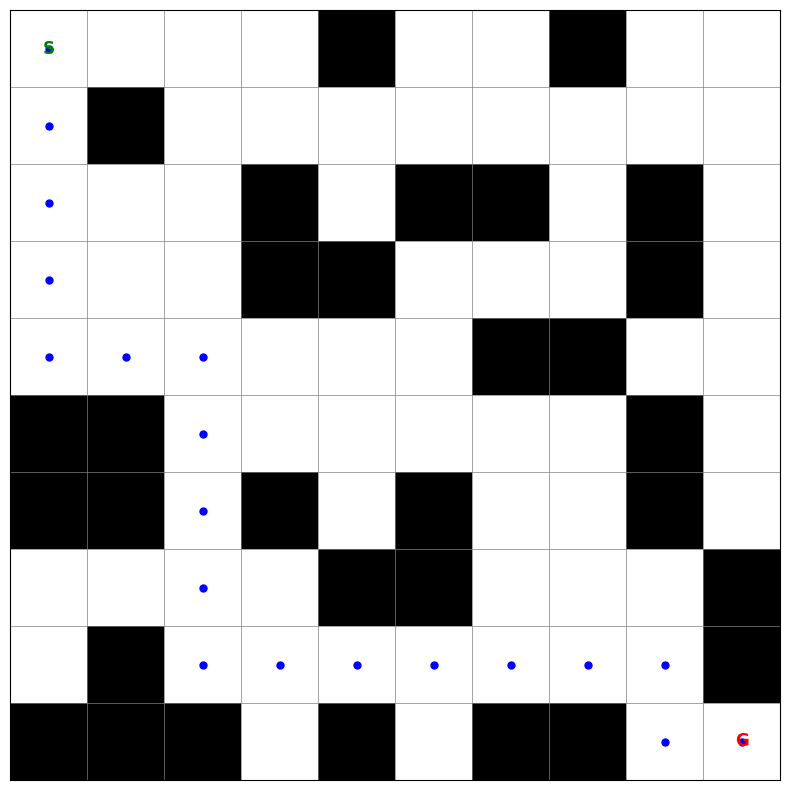

In [251]:
def greedy_best_first_search(problem):
    """
    Performs Greedy Best-First Search on the given problem.

    Args:
        problem: A problem instance with methods:
                 - problem.init_state: the initial state
                 - problem.goal_test(state): returns True if the state is the goal
                 - problem.actions(state): returns available actions for a state
                 - problem.result(state, action): returns the resulting state after taking an action
                 - problem.heuristic(state): estimated cost to goal from a state

    Returns:
        A tuple containing:
        - solution: a sequence of actions leading to the goal, or None if no solution exists
        - max_frontier_size: the maximum number of nodes in the frontier during the search
    """
    frontier = []
    # Push the initial state with the heuristic value as priority
    initial_node = Node.root(problem.init_state)
    heapq.heappush(frontier, (problem.heuristic(initial_node.state), initial_node))
    visited = set()
    visited.add(problem.init_state)
    max_frontier_size = 1

    while frontier:
        # Pop the node with the lowest heuristic value
        h_cost, node = heapq.heappop(frontier)

        if problem.goal_test(node.state):
            return node.path(), max_frontier_size  # Return the path found

        # Generate children nodes
        children = [Node.child(problem, node, action) for action in problem.actions(node.state)]
        for child in children:
            if child.state not in visited:
                visited.add(child.state)
                # Use heuristic value as the priority
                h_cost = problem.heuristic(child.state)
                heapq.heappush(frontier, (h_cost, child))

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None, max_frontier_size



# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = np.random.choice([0, 1], size=(rows, cols), p=[0.3, 0.7])
maze[0][0] = maze[rows-1][cols-1] = 1  # Ensure start and goal are paths

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform Greedy Best-First Search
path, _ = greedy_best_first_search(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)

In [252]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = greedy_best_first_search(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8), (9, 8), (9, 9)]
Max frontier size: 12


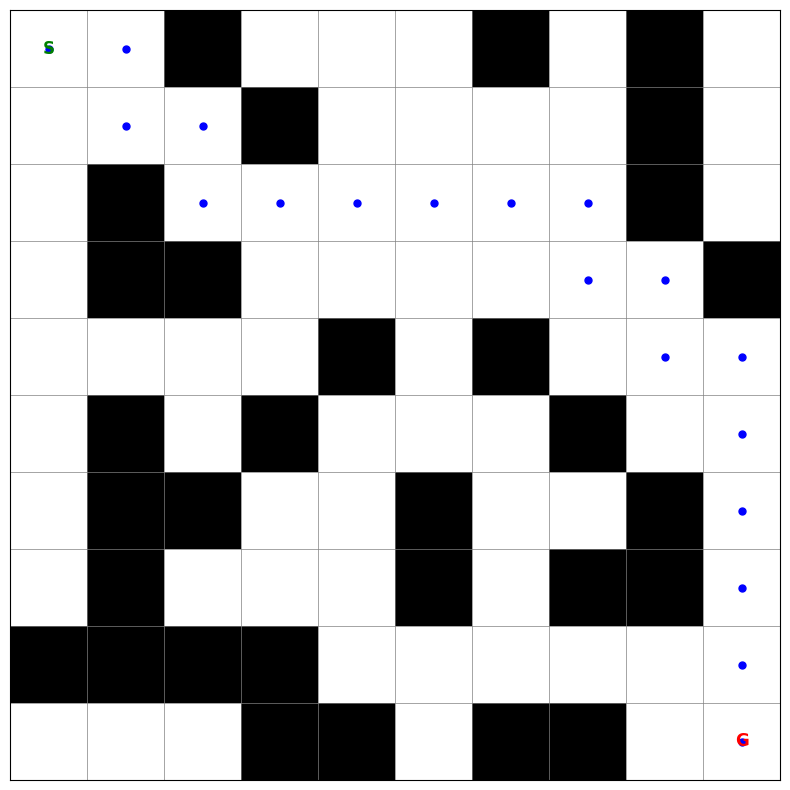

In [254]:
def depth_limited_search(problem, limit=5):
    """Iterative implementation of depth-limited search."""
    stack = [(Node.root(problem.init_state), 0)]  # Stack of (node, depth)
    visited = set()
    visited.add(problem.init_state)

    while stack:
        node, depth = stack.pop()
        if problem.goal_test(node.state):
            return node  # Return the node when goal is found
        if depth < limit:
            for action in problem.actions(node.state):
                child = Node.child(problem, node, action)
                if child.state not in visited:
                    visited.add(child.state)
                    stack.append((child, depth + 1))

    return 'cutoff'  # Return 'cutoff' if the search goes beyond the depth limit


def iterative_deepening_search(problem, verbose=False):
    """Iterative Deepening Search."""
    max_frontier_size = 1  # Track the max size of the frontier

    for depth in range(sys.maxsize):  # Unbounded loop
        if verbose:
            print(f"Depth: {depth}")
        result = depth_limited_search(problem, limit=depth)

        if result != 'cutoff':
            actions = solution(result)  # Get the solution path from the node
            return actions, max_frontier_size

        # Track the maximum depth explored
        max_frontier_size = max(max_frontier_size, depth)

    return None, max_frontier_size

# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = np.random.choice([0, 1], size=(rows, cols), p=[0.3, 0.7])
maze[0][0] = maze[rows-1][cols-1] = 1  # Ensure start and goal are paths

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform Greedy Best-First Search
path, _ = iterative_deepening_search(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)

In [255]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = iterative_deepening_search(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 7), (3, 8), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]
Max frontier size: 17


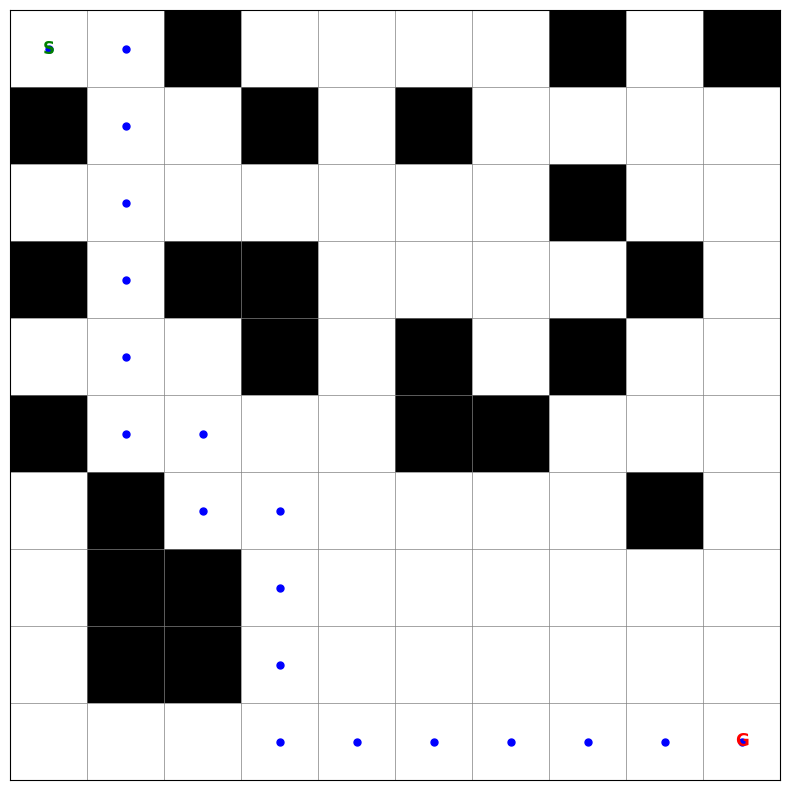

In [256]:
# Hill climbing search
def hill_climbing(problem):
    """Perform Hill Climbing search on a given problem."""
    current = Node.root(problem.init_state)
    max_frontier_size = 0
    frontier = [current]  # Track all visited nodes for visualization (if needed)

    while True:
        # Get all neighbors
        neighbors = [Node.child(problem, current, action) for action in problem.actions(current.state)]

        # Track frontier size
        max_frontier_size = max(max_frontier_size, len(neighbors))

        # No neighbors means we can't proceed further
        if not neighbors:
            break

        # Choose the neighbor with the least heuristic value (fewer conflicts)
        next_node = min(neighbors, key=lambda node: problem.heuristic(node.state))

        # If no better neighbor is found, stop the search
        if problem.heuristic(next_node.state) >= problem.heuristic(current.state):
            break

        # Move to the better neighbor
        current = next_node
        frontier.append(current)

    # Return the path and the maximum frontier size
    return current.path(), max_frontier_size





# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = np.random.choice([0, 1], size=(rows, cols), p=[0.3, 0.7])
maze[0][0] = maze[rows-1][cols-1] = 1  # Ensure start and goal are paths

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform Greedy Best-First Search
path, _ = hill_climbing(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)


In [257]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = hill_climbing(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (6, 2), (6, 3), (7, 3), (8, 3), (9, 3), (9, 4), (9, 5), (9, 6), (9, 7), (9, 8), (9, 9)]
Max frontier size: 4


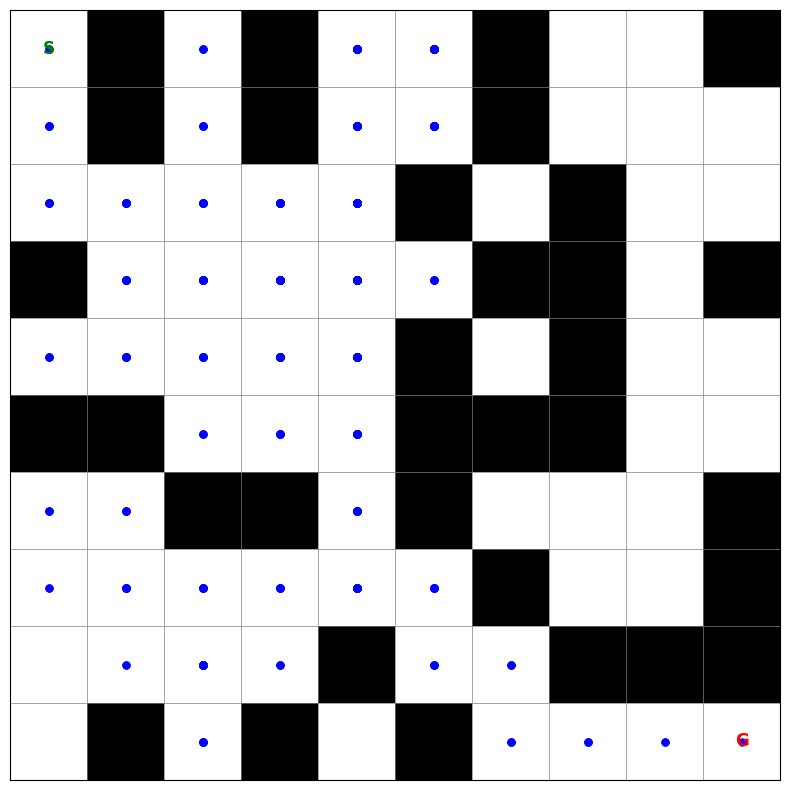

In [276]:
import math
import random
from itertools import count

def simulated_annealing(problem, verbose=False):
    """Simulated annealing search implementation with an internal schedule."""
    def schedule(t):
        """Example schedule: Exponential decay."""
        initial_temp = 100
        decay_rate = 0.01
        return initial_temp * math.exp(-decay_rate * t)

    current_state = problem.init_state
    current_value = problem.heuristic(current_state)

    # Initialize path as an empty list to store the search path
    path = [current_state]  # Start with the initial state in the path

    if verbose:
        print(f"Initial state: {current_state}, Value: {current_value}")

    for t in count():
        T = schedule(t)  # Temperature as a function of the step count
        if T == 0 or current_value == 0:  # Stop if temperature is zero or goal is reached
            return path, None  # Return the path and None for max_frontier_size (not applicable here)

        next_states = [problem.result(current_state, action) for action in problem.actions(current_state)]
        next_state = random.choice(next_states)
        next_value = problem.heuristic(next_state)
        delta = current_value - next_value

        if delta > 0 or random.random() < math.exp(delta / T):
            current_state, current_value = next_state, next_value
            path.append(current_state)  # Add the state to the path


# Example usage
rows, cols = 10, 10  # Maze dimensions
maze = np.random.choice([0, 1], size=(rows, cols), p=[0.3, 0.7])
maze[0][0] = maze[rows-1][cols-1] = 1  # Ensure start and goal are paths

# Create the problem with start and goal positions
init_state = (0, 0)  # Start at top-left corner
goal_state = (rows-1, cols-1)  # Goal at bottom-right corner
problem = Problem(maze, init_state, goal_state)

# Perform Greedy Best-First Search
path, _ = simulated_annealing(problem)

# Visualize the maze with the found path
visualize_maze(maze, path)

In [259]:
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)
path, max_frontier_size = simulated_annealing(problem)
print("Path to goal:", path if path else "No path found")
print("Max frontier size:", max_frontier_size)

Path to goal: [(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (

In [260]:
from random import randint, random, choice
from collections import deque

In [261]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# Define the genetic algorithm functions
class GeneticAlgorithm:
    def __init__(self, problem, population_size=100, generations=1000, mutation_rate=0.1, crossover_rate=0.7):
        self.problem = problem
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.population = self.generate_initial_population()

    def generate_initial_population(self):
        population = []
        for _ in range(self.population_size):
            # Each individual is a random path from start to goal
            path = self.generate_random_path()
            population.append(path)
        return population

    def generate_random_path(self):
        path = [self.problem.init_state]
        current_state = self.problem.init_state
        while current_state != self.problem.goal_state:
            actions = self.problem.actions(current_state)
            if not actions:
                break
            current_state = random.choice(actions)
            path.append(current_state)
        return path

    def fitness(self, path):
        # Fitness is inversely proportional to path length + heuristic distance from the goal
        path_length = len(path)
        goal_distance = self.problem.heuristic(path[-1])
        return 1 / (path_length + goal_distance)

    def select_parents(self):
        # Use tournament selection to choose two parents
        tournament_size = 5
        parents = []
        for _ in range(2):
            tournament = random.sample(self.population, tournament_size)
            tournament = sorted(tournament, key=lambda path: self.fitness(path), reverse=True)
            parents.append(tournament[0])
        return parents

    def crossover(self, parent1, parent2):
        if random.random() > self.crossover_rate:
            return parent1, parent2

        crossover_point = random.randint(1, min(len(parent1), len(parent2)) - 1)
        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]
        return child1, child2

    def mutate(self, path):
        if random.random() > self.mutation_rate:
            return path

        mutation_point = random.randint(1, len(path) - 1)
        current_state = path[mutation_point]
        actions = self.problem.actions(current_state)
        if actions:
            new_state = random.choice(actions)
            path[mutation_point] = new_state
        return path

    def evolve(self):
        for generation in range(self.generations):
            # Create a new generation
            new_population = []
            while len(new_population) < self.population_size:
                parents = self.select_parents()
                child1, child2 = self.crossover(parents[0], parents[1])
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)
                new_population.extend([child1, child2])

            self.population = new_population[:self.population_size]

    def get_best_solution(self):
        best_path = max(self.population, key=lambda path: self.fitness(path))
        return best_path

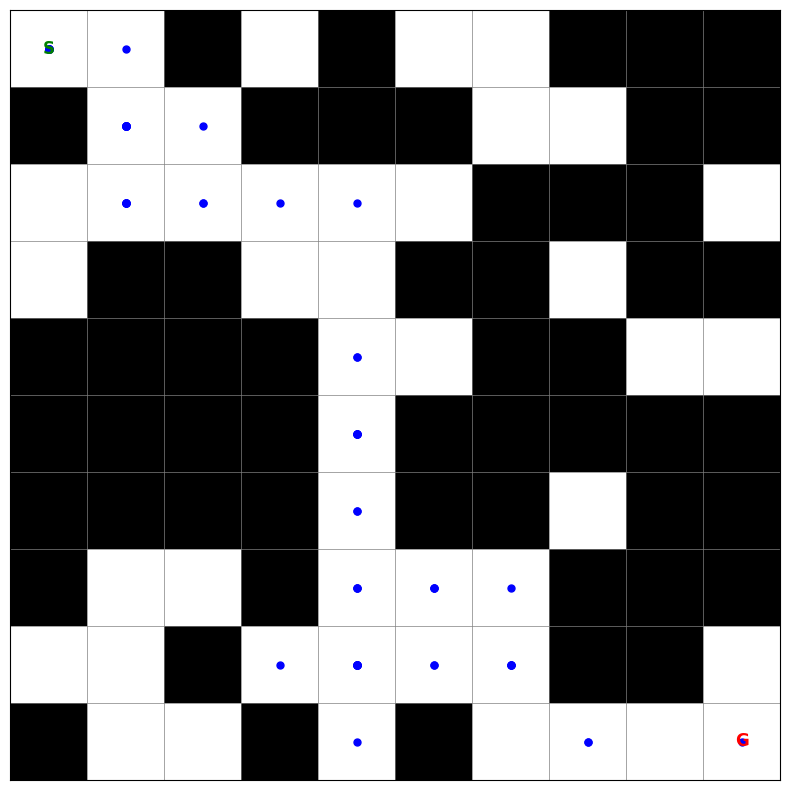

In [262]:
# Define the maze problem
rows, cols = 10, 10
maze = generate_maze(rows, cols)
init_state = (0, 0)
goal_state = (rows - 1, cols - 1)
problem = Problem(maze, init_state, goal_state)

# Run the genetic algorithm
ga = GeneticAlgorithm(problem)
ga.evolve()

# Get the best solution (path)
best_path = ga.get_best_solution()

# Visualize the maze and the path found by the genetic algorithm
visualize_maze(maze, path=best_path)


In [263]:
import time

In [264]:
def measure_performance(search_function, problem, heuristic_fn=None , verbose=False):
    start_time = time.time()  # Record start time
    solution_path, max_frontier_size = search_function(problem)  # Run the search function
    elapsed_time = time.time() - start_time  # Calculate the elapsed time

    # If no solution was found, set cost to infinity
    cost = solution_path if isinstance(solution_path, int) else len(solution_path) if solution_path else float('inf')

    if verbose:
        print(f"Algorithm: {search_function.__name__}")
        print(f"Elapsed Time: {elapsed_time:.4f} seconds")
        print(f"Max Frontier Size: {max_frontier_size}")
        print(f"Solution: {solution_path}")
        print(f"Cost: {cost}")
        print('-' * 40)

    # Return performance metrics
    return {
        'solution': solution_path,
        'cost': cost,
        'elapsed_time': elapsed_time,
        'max_frontier_size': max_frontier_size
    }


In [265]:
measure_performance(breadth_first_tree_search, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (8, 4),
  (8, 5),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.00025010108947753906,
 'max_frontier_size': 4}

In [266]:
measure_performance(uniform_cost_search, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (8, 4),
  (8, 5),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.00021719932556152344,
 'max_frontier_size': 4}

In [267]:
measure_performance(depth_first_tree_search, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (1, 2),
  (2, 2),
  (2, 3),
  (2, 4),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (7, 5),
  (7, 6),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.0002117156982421875,
 'max_frontier_size': 5}

In [268]:
# measure_performance(iterative_deepening_search, problem)

In [269]:
measure_performance(A_star_search_With_manhattan_distance, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (8, 4),
  (8, 5),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.00035953521728515625,
 'max_frontier_size': 5}

In [270]:
measure_performance(A_star_search_With_euclidean_distance,problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (7, 5),
  (7, 6),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.00034046173095703125,
 'max_frontier_size': 4}

In [271]:
measure_performance(greedy_best_first_search, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (8, 4),
  (8, 5),
  (8, 6),
  (9, 6),
  (9, 7),
  (9, 8),
  (9, 9)],
 'cost': 19,
 'elapsed_time': 0.00026035308837890625,
 'max_frontier_size': 8}

In [272]:
measure_performance(hill_climbing, problem)

{'solution': [(0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (7, 4),
  (8, 4),
  (9, 4)],
 'cost': 14,
 'elapsed_time': 0.00019288063049316406,
 'max_frontier_size': 4}

In [273]:
measure_performance(simulated_annealing, problem)

{'solution': [(0, 0),
  (0, 1),
  (0, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (1, 1),
  (0, 1),
  (0, 0),
  (0, 1),
  (1, 1),
  (0, 1),
  (1, 1),
  (1, 2),
  (1, 1),
  (1, 2),
  (1, 1),
  (1, 2),
  (2, 2),
  (1, 2),
  (1, 1),
  (0, 1),
  (1, 1),
  (1, 2),
  (1, 1),
  (2, 1),
  (2, 0),
  (3, 0),
  (2, 0),
  (2, 1),
  (2, 0),
  (3, 0),
  (2, 0),
  (2, 1),
  (2, 0),
  (2, 1),
  (2, 0),
  (3, 0),
  (2, 0),
  (2, 1),
  (1, 1),
  (0, 1),
  (0, 0),
  (0, 1),
  (0, 0),
  (0, 1),
  (0, 0),
  (0, 1),
  (1, 1),
  (0, 1),
  (1, 1),
  (2, 1),
  (1, 1),
  (1, 2),
  (1, 1),
  (2, 1),
  (2, 0),
  (3, 0),
  (2, 0),
  (2, 1),
  (2, 0),
  (2, 1),
  (2, 2),
  (2, 3),
  (3, 3),
  (2, 3),
  (2, 2),
  (2, 3),
  (3, 3),
  (3, 4),
  (2, 4),
  (2, 5),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (4, 4),
  (5, 4),
  (4, 4),
  (4, 5),
  (4, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (4, 4),
  (3, 4),
  (2, 4),
  (2, 5),
  (2, 4),
  (3, 4),
  (4, 4),
  (5, 4),
  (6, 4),
  (5, 4),
  (6, 4),
  (5, 4),
  (4, 4),
  (3, 4),
  (3, 3)

In [274]:
from tabulate import tabulate

In [275]:
from tabulate import tabulate

# Measure performance for all three algorithms
bfs_tree_performance = measure_performance(breadth_first_tree_search, problem, verbose=True)
dfs_graph_performance = measure_performance(depth_first_tree_search, problem, verbose=True)
uniform_cost_search_performance = measure_performance(uniform_cost_search, problem, verbose=True)
iterative_deepening_search_performance = measure_performance(iterative_deepening_search, problem, verbose=True)
greedy_best_first_search_performance = measure_performance(greedy_best_first_search, problem, verbose=True)
A_star_search_With_manhattan_distance_performance = measure_performance(A_star_search_With_manhattan_distance, problem, verbose=True)
A_star_search_With_euclidean_distance_performance = measure_performance(A_star_search_With_euclidean_distance, problem, verbose=True)
hill_climbing_performance = measure_performance(hill_climbing, problem, verbose=True)
simulated_annealing_performance = measure_performance(simulated_annealing, problem, verbose=True)

# Prepare the data for the table
headers = ["Algorithm", "Solution", "Cost", "Time (seconds)", "Max Frontier Size (bits)"]
table_data = [
    ["BFS Tree", bfs_tree_performance['solution'], bfs_tree_performance['cost'],
     f"{bfs_tree_performance['elapsed_time']:.4f}", bfs_tree_performance['max_frontier_size']],
    ["DFS Graph", dfs_graph_performance['solution'], dfs_graph_performance['cost'],
     f"{dfs_graph_performance['elapsed_time']:.4f}", dfs_graph_performance['max_frontier_size']],
    ["UCS Graph", uniform_cost_search_performance['solution'], uniform_cost_search_performance['cost'],
     f"{uniform_cost_search_performance['elapsed_time']:.4f}", uniform_cost_search_performance['max_frontier_size']],
    ["IDS", iterative_deepening_search_performance['solution'], iterative_deepening_search_performance['cost'],
     f"{iterative_deepening_search_performance['elapsed_time']:.4f}", iterative_deepening_search_performance['max_frontier_size']],
    ["Greedy BFS", greedy_best_first_search_performance['solution'], greedy_best_first_search_performance['cost'],
     f"{greedy_best_first_search_performance['elapsed_time']:.4f}", greedy_best_first_search_performance['max_frontier_size']],
    ["A star search With manhattan distance", A_star_search_With_manhattan_distance_performance['solution'],
     A_star_search_With_manhattan_distance_performance['cost'],
     f"{A_star_search_With_manhattan_distance_performance['elapsed_time']:.4f}",
     A_star_search_With_manhattan_distance_performance['max_frontier_size']],
    ["A star search With euclidean distance", A_star_search_With_euclidean_distance_performance['solution'],
     A_star_search_With_euclidean_distance_performance['cost'],
     f"{A_star_search_With_euclidean_distance_performance['elapsed_time']:.4f}",
     A_star_search_With_euclidean_distance_performance['max_frontier_size']],
    ["Hill Climbing", hill_climbing_performance['solution'], hill_climbing_performance['cost'],
     f"{hill_climbing_performance['elapsed_time']:.4f}", hill_climbing_performance['max_frontier_size']],
    ["Simulated Annealing", simulated_annealing_performance['solution'], simulated_annealing_performance['cost'],
     f"{simulated_annealing_performance['elapsed_time']:.4f}", simulated_annealing_performance['max_frontier_size']]
]

# Print the table
print(tabulate(table_data, headers=headers, tablefmt='grid'))


Algorithm: breadth_first_tree_search
Elapsed Time: 0.0002 seconds
Max Frontier Size: 4
Solution: [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (5, 4), (6, 4), (7, 4), (8, 4), (8, 5), (8, 6), (9, 6), (9, 7), (9, 8), (9, 9)]
Cost: 19
----------------------------------------
Algorithm: depth_first_tree_search
Elapsed Time: 0.0002 seconds
Max Frontier Size: 5
Solution: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (5, 4), (6, 4), (7, 4), (7, 5), (7, 6), (8, 6), (9, 6), (9, 7), (9, 8), (9, 9)]
Cost: 19
----------------------------------------
Algorithm: uniform_cost_search
Elapsed Time: 0.0002 seconds
Max Frontier Size: 4
Solution: [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (5, 4), (6, 4), (7, 4), (8, 4), (8, 5), (8, 6), (9, 6), (9, 7), (9, 8), (9, 9)]
Cost: 19
----------------------------------------
Algorithm: iterative_deepening_search
Elapsed Time: 0.0016 seconds
Max Frontier Size: 17
Solution: [(0, 0), 